# BeeCounter results

Plots the estimated total number of bees per hive over time, from the labeling sessions stored in `results/bee_counts.csv`. Each session covers one hive at one timestamp; the raw total is the sum of `estimated_total_bees` across its 4 camera rows.

`HiveBeeCountEstimator` (in `bee_count_estimator.py`) then corrects those raw totals: since no brood was present, a hive's population can only decrease over time, and since dense clusters hide bees, a raw total can only be an underestimate. So each corrected value is the largest raw total observed from that session onward — the smallest non-increasing sequence that stays at or above every raw observation.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

from bee_count_estimator import HiveBeeCountEstimator

## Load raw and corrected estimates

In [5]:
estimator = HiveBeeCountEstimator()
sessions = estimator.corrected_estimates().sort_values("timestamp")

incomplete = sessions[sessions["n_cameras"] < 4]
if len(incomplete):
    print(f"Warning: {len(incomplete)} session(s) have fewer than 4 labeled cameras:")
    print(incomplete)

sessions

,session_id,hive,timestamp,n_cameras,raw_total_bees,corrected_total_bees
0,b11887482b61,1,2024-10-15 04:00:00+00:00,4,2015.0,2015.0
7,6ee6879db992,2,2024-10-16 04:20:00+00:00,4,1961.0,1961.0
8,420ceaf237aa,2,2024-11-10 16:20:00+00:00,4,1238.0,1238.0
1,48aec58c4d2c,1,2024-11-20 12:20:00+00:00,4,1728.0,1728.0
9,b301301d200d,2,2024-11-21 16:40:00+00:00,4,1212.0,1212.0
2,f1edc123df7c,1,2024-11-29 04:00:00+00:00,4,1562.0,1562.0
10,81ae31e3dab6,2,2024-11-29 04:00:00+00:00,4,958.0,958.0
3,eec0a71ac8da,1,2024-12-02 05:00:00+00:00,4,1376.0,1376.0
11,921b45f3d14a,2,2024-12-07 04:00:00+00:00,4,701.0,721.0
4,af71ad8af07f,1,2024-12-12 03:40:00+00:00,4,1191.0,1191.0


## Total bees over time, per hive

Solid line: corrected estimate. Faint dashed line: raw estimate, for reference — the gap between the two marks where the correction pulled a value up to stay consistent with a later, higher reading.

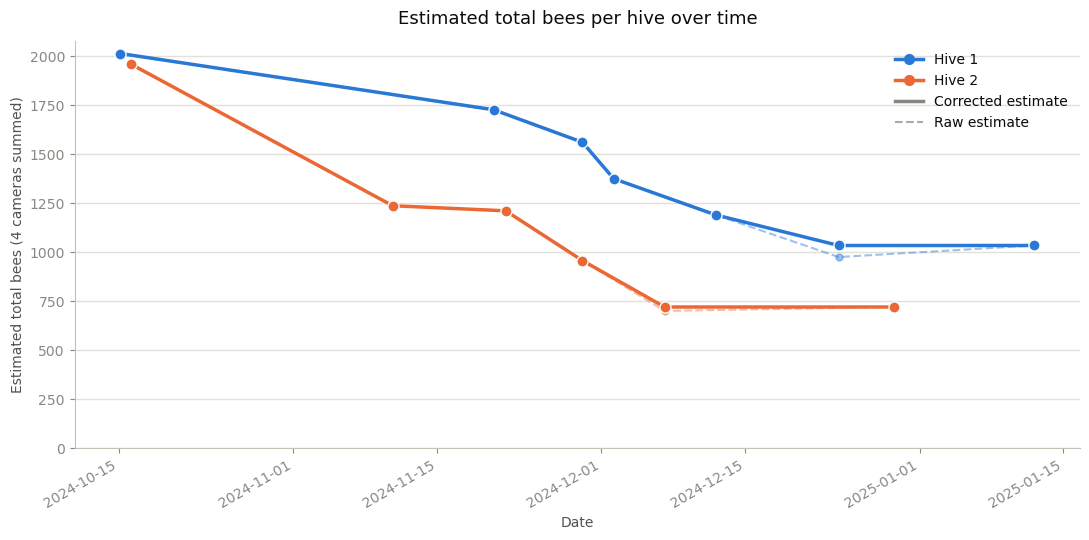

In [6]:
HIVE_COLORS = {1: "#2a78d6", 2: "#eb6834"}  # categorical slots 1 & 2

fig, ax = plt.subplots(figsize=(11, 5.5))

for hive, group in sessions.groupby("hive"):
    group = group.sort_values("timestamp")
    color = HIVE_COLORS.get(hive, "#4a3aa7")

    ax.plot(
        group["timestamp"], group["raw_total_bees"],
        color=color, alpha=0.45,
        linewidth=1.5, linestyle="--",
        marker="o", markersize=5,
        zorder=2,
    )
    ax.plot(
        group["timestamp"], group["corrected_total_bees"],
        color=color,
        linewidth=2.5, marker="o", markersize=8,
        markerfacecolor=color, markeredgecolor="#fcfcfb", markeredgewidth=1,
        zorder=3,
    )

ax.set_title("Estimated total bees per hive over time", fontsize=13, color="#0b0b0b", pad=12)
ax.set_xlabel("Date", color="#52514e")
ax.set_ylabel("Estimated total bees (4 cameras summed)", color="#52514e")
ax.set_ylim(bottom=0)

ax.spines[["top", "right"]].set_visible(False)
ax.spines[["bottom", "left"]].set_color("#c3c2b7")
ax.tick_params(colors="#898781")
ax.yaxis.grid(True, color="#e1e0d9", linewidth=1)
ax.set_axisbelow(True)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
fig.autofmt_xdate()

hive_handles = [
    Line2D([0], [0], color=HIVE_COLORS.get(hive, "#4a3aa7"), linewidth=2.5, marker="o", markersize=7, label=f"Hive {hive}")
    for hive in sorted(sessions["hive"].unique())
]
style_handles = [
    Line2D([0], [0], color="#898781", linewidth=2.5, label="Corrected estimate"),
    Line2D([0], [0], color="#898781", linewidth=1.5, linestyle="--", alpha=0.7, label="Raw estimate"),
]
legend = ax.legend(handles=hive_handles + style_handles, frameon=False, loc="upper right")
for text in legend.get_texts():
    text.set_color("#0b0b0b")

fig.tight_layout()
plt.show()